# Лабораторная работа №5

## Ансамбли моделей машинного обучения. Часть 1


# Описание задания

Цель лабораторной работы: изучение ансамблей моделей машинного обучения.

Необходимо выполнить следующие действия:

- выбрать датасет для решения задачи классификации или регрессии;
- при необходимости обработать пропуски и закодировать категориальные признаки;
- с использованием `train_test_split` разделить выборку на обучающую и тестовую;
- обучить две модели группы бэггинга;
- обучить модель AdaBoost;
- обучить модель градиентного бустинга;
- оценить качество моделей с помощью подходящей метрики;
- сравнить качество полученных моделей.

В работе используется датасет **Titanic**. Решается задача бинарной классификации: необходимо предсказать, выжил пассажир (`Survived = 1`) или нет (`Survived = 0`).


# Текст программы

## Импорт библиотек


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

%matplotlib inline

sns.set_theme(style='ticks')

# Загрузка и первичный анализ данных


In [2]:
data = pd.read_csv('../2/titanic.csv')

data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
data.shape

(891, 12)

In [4]:
data.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [5]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
data['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

Text(0.5, 1.0, 'Распределение целевого признака Survived')

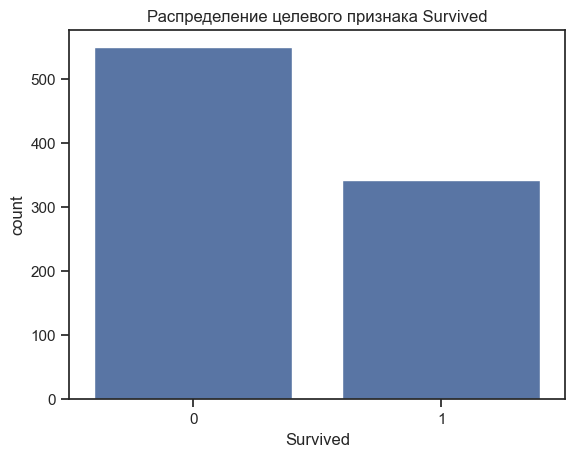

In [7]:
sns.countplot(x='Survived', data=data)
plt.title('Распределение целевого признака Survived')

# Подготовка данных

Обработаем пропуски и подготовим признаки:

- `Age` заполним медианой;
- `Embarked` заполним наиболее частым значением;
- `Cabin` заполним категорией `Unknown`;
- из `Cabin` выделим первую букву каюты (`CabinDeck`);
- удалим признаки `PassengerId`, `Name`, `Ticket`, `Cabin`;
- категориальные признаки закодируем с помощью one-hot encoding.


In [8]:
data_prepared = data.copy()

data_prepared['Age'] = data_prepared['Age'].fillna(data_prepared['Age'].median())
data_prepared['Embarked'] = data_prepared['Embarked'].fillna(data_prepared['Embarked'].mode()[0])
data_prepared['Cabin'] = data_prepared['Cabin'].fillna('Unknown')
data_prepared['CabinDeck'] = data_prepared['Cabin'].str[0]

data_prepared.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
CabinDeck      0
dtype: int64

In [9]:
model_data = data_prepared.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

model_data = pd.get_dummies(
    model_data,
    columns=['Sex', 'Embarked', 'CabinDeck'],
    drop_first=False
)

model_data.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,CabinDeck_A,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinDeck_U
0,0,3,22.0,1,0,7.2500,False,True,False,False,True,False,False,False,False,False,False,False,False,True
1,1,1,38.0,1,0,71.2833,True,False,True,False,False,False,False,True,False,False,False,False,False,False
2,1,3,26.0,0,0,7.9250,True,False,False,False,True,False,False,False,False,False,False,False,False,True
3,1,1,35.0,1,0,53.1000,True,False,False,False,True,False,False,True,False,False,False,False,False,False
4,0,3,35.0,0,0,8.0500,False,True,False,False,True,False,False,False,False,False,False,False,False,True


In [10]:
model_data.shape

(891, 20)

# Разделение выборки на обучающую и тестовую

Целевой признак - `Survived`. Используем стратифицированное разделение, чтобы сохранить соотношение классов в обучающей и тестовой выборках.


In [11]:
X = model_data.drop(columns=['Survived'])
y = model_data['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((668, 19), (223, 19), (668,), (223,))

In [12]:
pd.DataFrame({
    'train': y_train.value_counts(normalize=True),
    'test': y_test.value_counts(normalize=True)
})

,train,test
Survived,,
0,0.616766,0.61435
1,0.383234,0.38565


# Обучение ансамблевых моделей

Обучим четыре ансамблевые модели:

- `BaggingClassifier` как модель группы бэггинга;
- `RandomForestClassifier` как вторую модель группы бэггинга;
- `AdaBoostClassifier`;
- `GradientBoostingClassifier`.


## BaggingClassifier


In [13]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)

bagging_model.fit(X_train, y_train)

bagging_pred = bagging_model.predict(X_test)
bagging_pred[:20]

array([0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0])

## RandomForestClassifier


In [14]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

random_forest_pred = random_forest_model.predict(X_test)
random_forest_pred[:20]

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

## AdaBoostClassifier


In [15]:
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

adaboost_model.fit(X_train, y_train)

adaboost_pred = adaboost_model.predict(X_test)
adaboost_pred[:20]

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0])

## GradientBoostingClassifier


In [16]:
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(X_train, y_train)

gradient_boosting_pred = gradient_boosting_model.predict(X_test)
gradient_boosting_pred[:20]

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

# Оценка качества моделей

Для сравнения моделей используем метрику `f1`, так как она учитывает и точность, и полноту. Дополнительно рассчитаем `accuracy`, `precision` и `recall`.


In [17]:
def get_classification_metrics(y_true, y_pred, model_name):
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
    }

metrics_df = pd.DataFrame([
    get_classification_metrics(y_test, bagging_pred, 'BaggingClassifier'),
    get_classification_metrics(y_test, random_forest_pred, 'RandomForestClassifier'),
    get_classification_metrics(y_test, adaboost_pred, 'AdaBoostClassifier'),
    get_classification_metrics(y_test, gradient_boosting_pred, 'GradientBoostingClassifier')
])

metrics_df

,model,accuracy,precision,recall,f1
0,BaggingClassifier,0.784753,0.763889,0.639535,0.696203
1,RandomForestClassifier,0.798206,0.797101,0.639535,0.709677
2,AdaBoostClassifier,0.766816,0.684783,0.732558,0.707865
3,GradientBoostingClassifier,0.820628,0.828571,0.674419,0.743590


In [18]:
print('BaggingClassifier')
print(classification_report(y_test, bagging_pred))

print('RandomForestClassifier')
print(classification_report(y_test, random_forest_pred))

print('AdaBoostClassifier')
print(classification_report(y_test, adaboost_pred))

print('GradientBoostingClassifier')
print(classification_report(y_test, gradient_boosting_pred))

BaggingClassifier
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       137
           1       0.76      0.64      0.70        86

    accuracy                           0.78       223
   macro avg       0.78      0.76      0.76       223
weighted avg       0.78      0.78      0.78       223

RandomForestClassifier
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       137
           1       0.80      0.64      0.71        86

    accuracy                           0.80       223
   macro avg       0.80      0.77      0.78       223
weighted avg       0.80      0.80      0.79       223

AdaBoostClassifier
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       137
           1       0.68      0.73      0.71        86

    accuracy                           0.77       223
   macro avg       0.75      0.76      0.76       223
weighted avg  

# Сравнение качества моделей


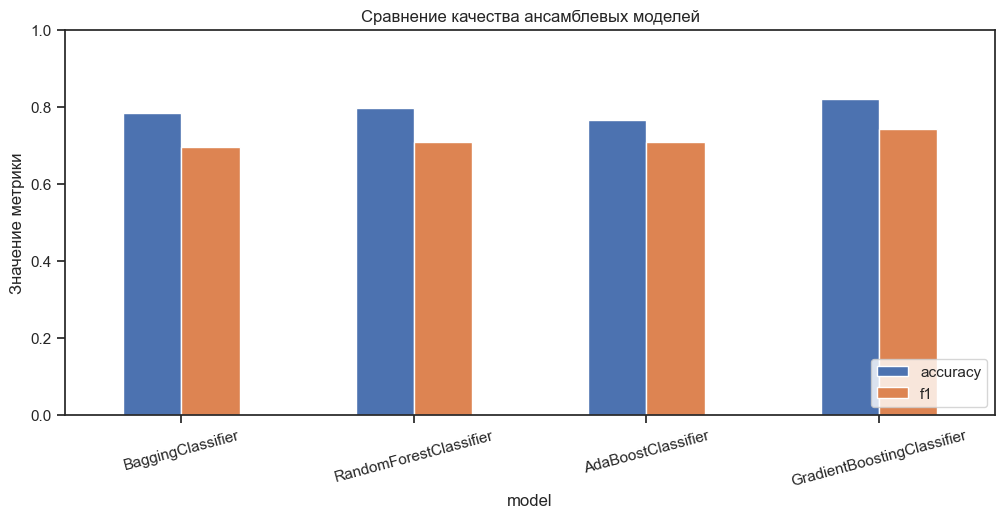

In [19]:
metrics_plot = metrics_df.set_index('model')

metrics_plot[['accuracy', 'f1']].plot(kind='bar', figsize=(12, 5))
plt.ylim(0, 1)
plt.title('Сравнение качества ансамблевых моделей')
plt.ylabel('Значение метрики')
plt.xticks(rotation=15)
plt.legend(loc='lower right')

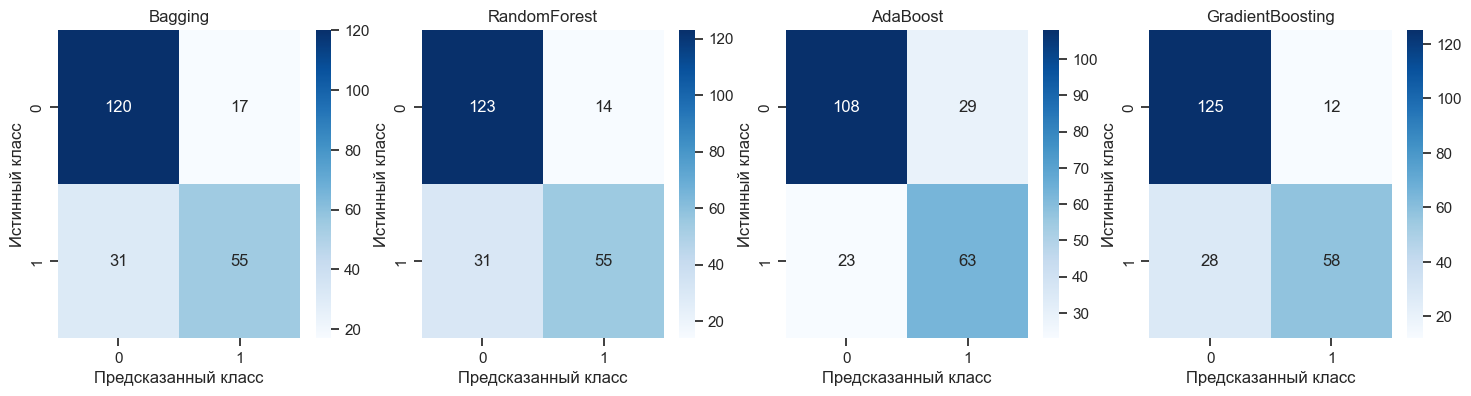

In [20]:
fig, ax = plt.subplots(1, 4, figsize=(18, 4))

for current_ax, y_pred, title in zip(
    ax,
    [bagging_pred, random_forest_pred, adaboost_pred, gradient_boosting_pred],
    ['Bagging', 'RandomForest', 'AdaBoost', 'GradientBoosting']
):
    sns.heatmap(confusion_matrix(y_test, y_pred),
                annot=True,
                fmt='d',
                cmap='Blues',
                ax=current_ax)
    current_ax.set_title(title)
    current_ax.set_xlabel('Предсказанный класс')
    current_ax.set_ylabel('Истинный класс')

In [21]:
best_model = metrics_df.sort_values('f1', ascending=False).iloc[0]
best_model

model        GradientBoostingClassifier
accuracy                       0.820628
precision                      0.828571
recall                         0.674419
f1                              0.74359
Name: 3, dtype: object

# Важность признаков в случайном лесу

Для дополнительной интерпретации посмотрим важность признаков в модели `RandomForestClassifier`.


In [22]:
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': random_forest_model.feature_importances_
}).sort_values('importance', ascending=False)

feature_importances.head(15)

,feature,importance
6,Sex_male,0.266802
5,Sex_female,0.229496
4,Fare,0.124425
1,Age,0.093343
0,Pclass,0.089617
18,CabinDeck_U,0.060741
3,Parch,0.032066
2,SibSp,0.028908
9,Embarked_S,0.014315
7,Embarked_C,0.012961


Text(0, 0.5, 'Признак')

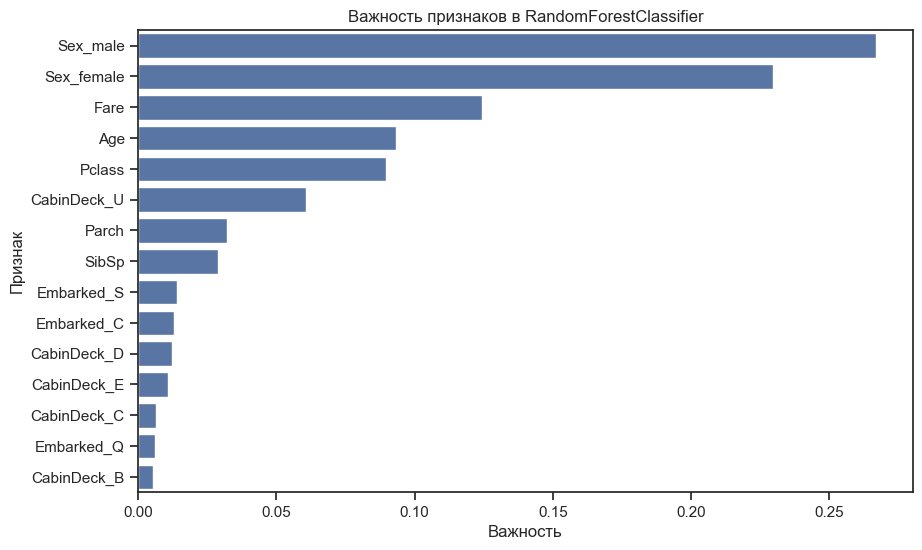

In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importances.head(15),
    x='importance',
    y='feature'
)

plt.title('Важность признаков в RandomForestClassifier')
plt.xlabel('Важность')
plt.ylabel('Признак')

# Выводы

В ходе лабораторной работы была решена задача классификации на датасете **Titanic** с использованием ансамблевых моделей.

Были выполнены следующие действия:

- проведена подготовка данных: заполнены пропуски и закодированы категориальные признаки;
- выборка разделена на обучающую и тестовую с помощью `train_test_split`;
- обучены две модели группы бэггинга: `BaggingClassifier` и `RandomForestClassifier`;
- обучены модели `AdaBoostClassifier` и `GradientBoostingClassifier`;
- качество моделей оценено с помощью метрики `f1`;
- дополнительно рассчитаны `accuracy`, `precision` и `recall`;
- построены графики для сравнения качества моделей и важности признаков.
